In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [2]:
# data to test with
bc = load_breast_cancer()
X = bc.data
y = bc.target

In [3]:

def best_split_point(X, y, column):
    ordering = np.argsort(X[:,column])
    classes = y[ordering]

    class_0_below = (classes == 0).cumsum()
    class_1_below = (classes == 1).cumsum()
    class_0_above = (classes == 0).sum() - (classes == 0).cumsum()
    class_1_above = (classes == 1).sum() - (classes == 1).cumsum()
    
    below_total = class_0_below + class_1_below
    above_total = class_0_above + class_1_above

    gini = class_1_below * class_0_below / (below_total ** 2 ) + \
           class_1_above * class_0_above / (above_total ** 2 )

    gini[np.isnan(gini)] = 1

    best_split_rank = np.argmin(gini)
    best_split_gini = gini[best_split_rank]
    best_split_index = np.argwhere(ordering == best_split_rank).item(0)
    best_split_value = X[best_split_index, column]
    
    return best_split_gini, best_split_value, column

class Node:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.is_leaf = True
        self.column = None
        self.split_point = None
        self.children = None
    
    def formatted(self, indent=0):
        if self.is_leaf:
            s = "Leaf({p[0]:.3f}, {p[1]:.3f})".format(p=self.probabilities())
        else:
            s = "Branch(X{column} <= {split_point})\n{left}\n{right}".format(
                column=self.column, 
                split_point=self.split_point,
                left=self.children[0].formatted(indent+1),
                right=self.children[1].formatted(indent+1))
            
        return "    " * indent + s

    def __str__(self):
        return self.formatted()
    
    def __repr__(self):
        return str(self)
    
    def split(self, depth=0):
        X, y = self.X, self.y
        if self.is_leaf and not self.is_pure():
            splits = [ best_split_point(X, y, column) for column in range(X.shape[1]) ]
            splits.sort()
            gini, split_point, column = splits[0]
            self.is_leaf = False
            self.column = column
            self.split_point = split_point
            
            below = X[:,column] <= split_point
            above = X[:,column] > split_point 
            
            self.children = [
                Node(X[below], y[below]),
                Node(X[above], y[above])
            ]
            
            if depth:
                for child in self.children:
                    child.split(depth-1)

    def probabilities(self):
        return np.array([
            np.mean(self.y == 0),
            np.mean(self.y == 1),
        ])
    
    def predict_proba(self, row):
        if self.is_leaf:
            return self.probabilities()
        else:
            if row[self.column] <= self.split_point:
                return self.children[0].predict_proba(row)
            else:
                return self.children[1].predict_proba(row)
    
    def is_pure(self):
        p = self.probabilities()
        if p[0] == 1 or p[1] == 1:
            return True
        return False

class DecisionTreeClassifier:
    def __init__(self, max_depth=3):
        self.max_depth = int(max_depth)
        self.root = None
        
    def fit(self, X, y):
        self.root = Node(X, y)
        self.root.split(self.max_depth)
        
    def predict_proba(self, X):
        results = []
        for row in X:
            p = self.root.predict_proba(row)
            results += [p]
        return np.array(results)
            
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)
        

In [28]:
n = Node(X, y)
n.split(depth=2)
n


/usr/local/lib/python3.5/dist-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in true_divide
  


Branch(X22 <= 89.04)
    Branch(X6 <= 0.0)
        Leaf(0.000, 1.000)
        Branch(X16 <= 0.0009737)
            Leaf(0.000, 1.000)
            Leaf(0.010, 0.990)
    Branch(X22 <= 96.42)
        Branch(X6 <= 0.004559)
            Leaf(0.000, 1.000)
            Leaf(0.074, 0.926)
        Branch(X26 <= 0.3169)
            Leaf(0.370, 0.630)
            Leaf(0.910, 0.090)

In [29]:

model = DecisionTreeClassifier(max_depth=3)
model.fit(X, y)
y_hat = model.predict(X)
p_hat = model.predict_proba(X)[:,1]

confusion_matrix(y, y_hat)




/usr/local/lib/python3.5/dist-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in true_divide
  


array([[193,  19],
       [ 18, 339]])

In [30]:
accuracy_score(y, y_hat)

0.9349736379613357

Text(0.4, 0.6, 'AUC: 0.958')

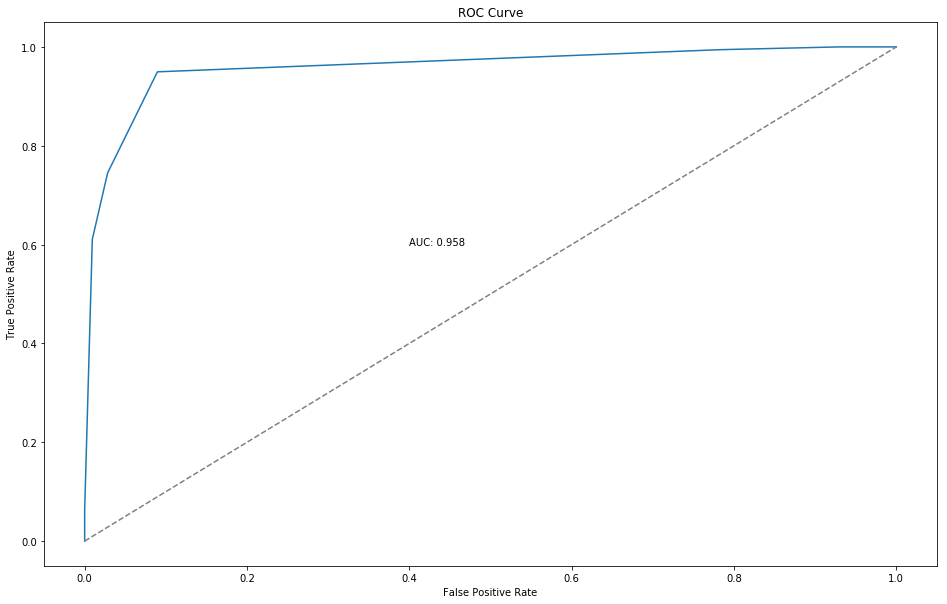

In [31]:
fpr, tpr, threshold = roc_curve(y, p_hat)
fpr = np.concatenate([[0], fpr])
tpr = np.concatenate([[0], tpr])
threshold = np.concatenate([[0], threshold])
plt.figure(figsize=(16,10))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.text(0.4, 0.6, 'AUC: {:.3f}'.format(roc_auc_score(y, p_hat)))

In [32]:
import pandas as pd
pd.DataFrame(dict(fpr=fpr, tpr=tpr, p=threshold))

,fpr,p,tpr
0,0.000000,0.000000,0.000000
1,0.000000,1.000000,0.061625
2,0.009434,0.989899,0.610644
3,0.028302,0.923077,0.745098
4,0.089623,0.848837,0.949580
5,0.783019,0.098160,0.994398
6,0.929245,0.060606,1.000000
7,1.000000,0.000000,1.000000


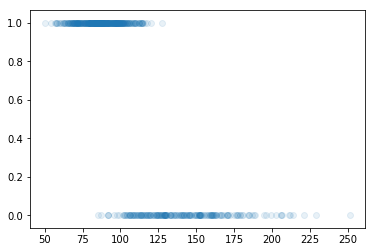

In [33]:
# quick check that the first split found makes sense
xy = np.array([X[:,22].flatten(), y]).T
plt.scatter(xy[:,0], xy[:,1], alpha=0.1)

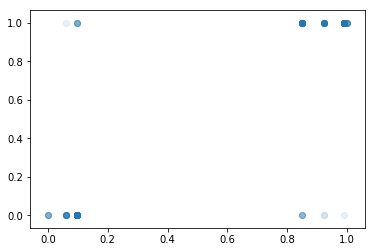

In [34]:
plt.scatter(p_hat, y, alpha=0.05)